# Feature Scaling

## a) Standardization

In [2]:
import numpy as np  # Lenear Algebra
import pandas as pd  # Data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('E:/Dataset/Social_Network_Ads.csv')

In [6]:
df = df.iloc[:, 2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
206,55,130000,1
245,51,146000,1
104,19,21000,0
340,53,104000,1
125,39,61000,0


### Splitting dataset

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=2)

In [22]:
print("Train data shape-",x_train.shape)
print("Test data shape-",x_test.shape)

Train data shape- (280, 2)
Test data shape- (120, 2)


### Data Preprocessing (Standard Scaler)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# Transform train, and test sets
x_train_scaled = scaler.transform(x_train)  # Array
x_test_scaled = scaler.transform(x_test)

In [37]:
scaler.mean_

array([3.77642857e+01, 6.99000000e+04])

In [39]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)  # Now pandas DataFrame

In [42]:
np.round(x_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


In [43]:
np.round(x_test_scaled.describe())

,Age,EstimatedSalary
count,120.0,120.0
mean,-0.0,-0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,-0.0
75%,1.0,1.0
max,2.0,2.0


### Effect of scaling

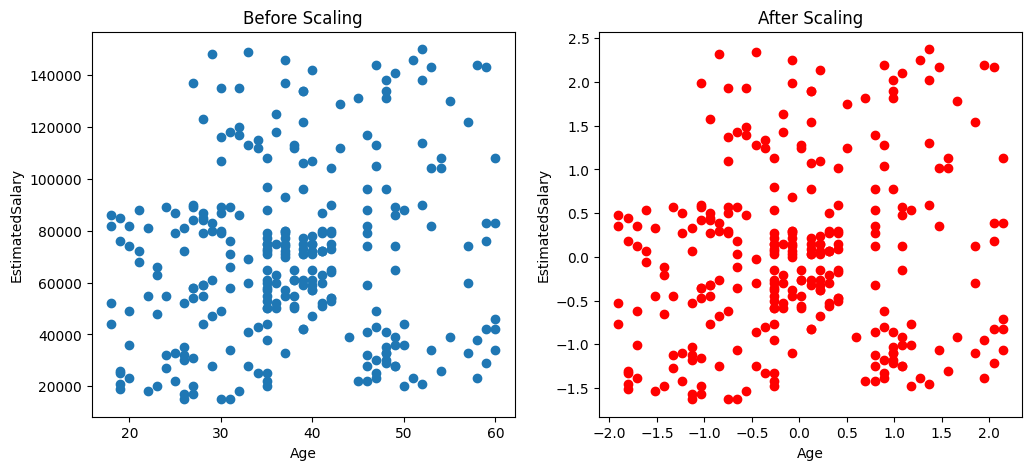

In [51]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(x=x_train['Age'], y=x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

ax2.scatter(x=x_train_scaled['Age'], y=x_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")
plt.show()

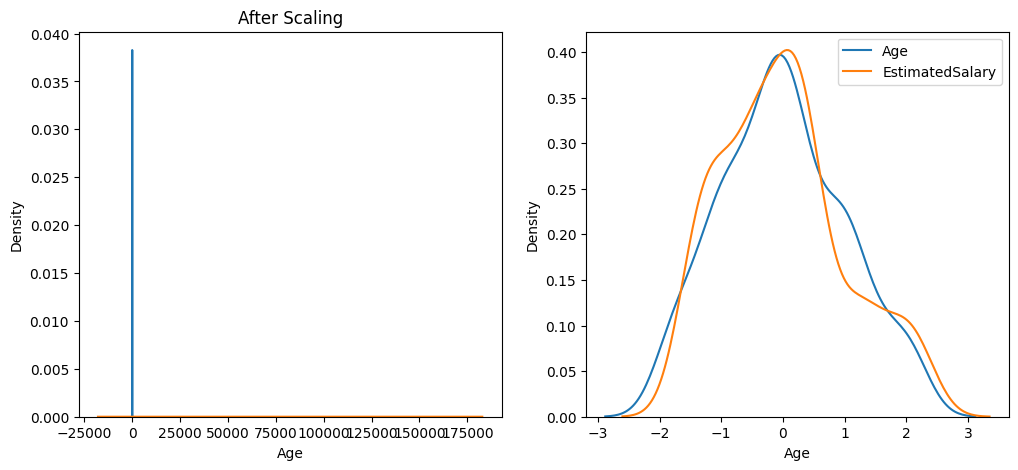

In [62]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
sns.kdeplot(x_train['Age'], ax=ax1, label='Age')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1, label='EstimatedSalary')
ax1.set_title("Before Scaling")

# After Scaling
sns.kdeplot(x_train_scaled['Age'], ax=ax2, label="Age")
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary')
ax1.set_title("After Scaling")

plt.legend()
plt.show()

### Comparison of Distribution

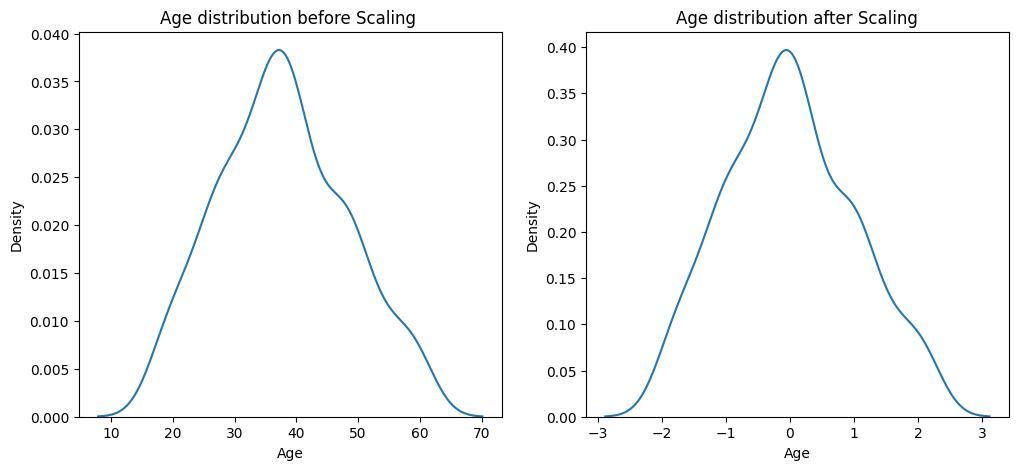

In [64]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(x_train['Age'], ax=ax1)
ax1.set_title("Age distribution before Scaling ")

sns.kdeplot(x_train_scaled['Age'], ax=ax2)
ax2.set_title("Age distribution after Scaling")
plt.show()

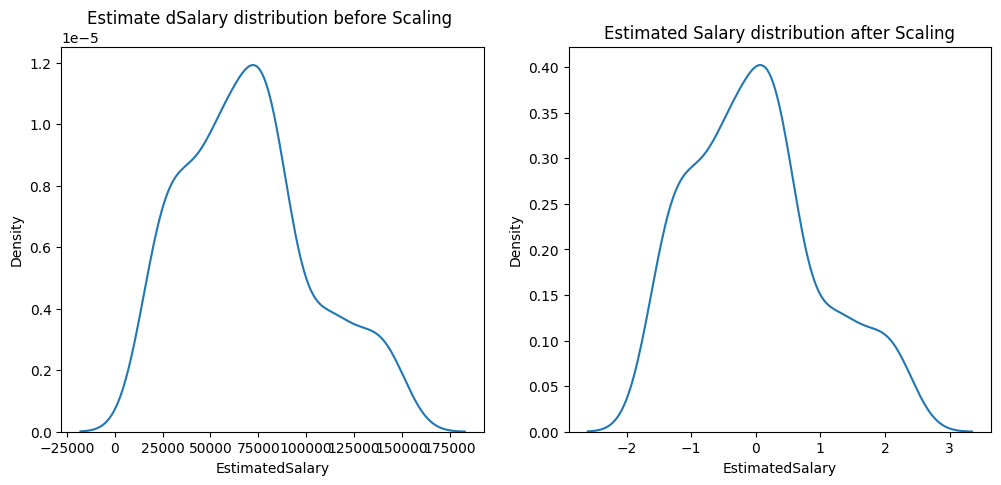

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)
ax1.set_title("Estimate dSalary distribution before Scaling ")

sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
ax2.set_title("Estimated Salary distribution after Scaling")
plt.show()

### Why scaling is important?

#### Logistic Regression eg-

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [75]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [77]:
from sklearn.metrics import accuracy_score

In [78]:
print("Actual :", accuracy_score(y_test, y_pred))
print("Scaled :", accuracy_score(y_test, y_pred_scaled))

Actual : 0.8416666666666667
Scaled : 0.8416666666666667


#### Decision Tree Classifier eg-

In [81]:
from sklearn.tree import DecisionTreeClassifier

In [82]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [83]:
dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [84]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [85]:
print("Actual :", accuracy_score(y_test, y_pred))
print("Scaled :", accuracy_score(y_test, y_pred_scaled))

Actual : 0.875
Scaled : 0.8833333333333333


## b) Normalization

### MinMax Scaling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading dataset

In [47]:
df = pd.read_csv('E:/Dataset/wine_data.csv', usecols=[0,1,2], dtype={0:'int64', 1:'float64', 2:'float64'})
df.columns = ['class_label', 'alcohol', 'malic_acid']

In [48]:
print(df.sample(5))
df.shape

     class_label  alcohol  malic_acid
49             1    13.94        1.73
60             2    12.33        1.10
144            3    12.25        3.88
108            2    12.22        1.29
92             2    12.69        1.53


(178, 3)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class_label  178 non-null    int64  
 1   alcohol      178 non-null    float64
 2   malic_acid   178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


#### data visualization

Text(0.5, 1.0, 'Malic Acid')

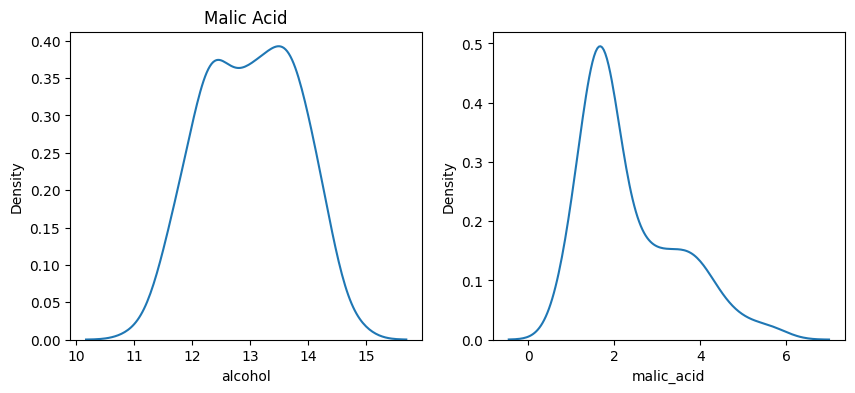

In [57]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))

sns.kdeplot(x=df['alcohol'], ax=ax1)
ax1.set_title("Age")

sns.kdeplot(df['malic_acid'], ax=ax2)
ax1.set_title("Malic Acid")

<Axes: xlabel='alcohol', ylabel='malic_acid'>

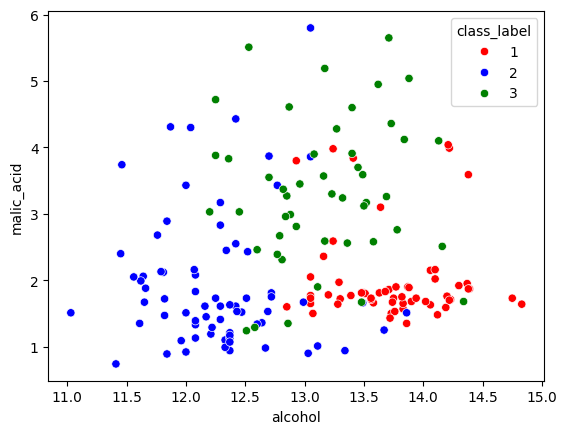

In [61]:
color_dict = {1:'red', 2:'blue', 3:'green'}
sns.scatterplot(x=df['alcohol'], y=df['malic_acid'], hue=df['class_label'], palette=color_dict)

#### splitting data

In [67]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(df.drop('class_label', axis=1), df['class_label'], test_size=0.3, random_state=2)

In [70]:
x_train.shape, x_test.shape

((124, 2), (54, 2))

#### data preprocessing (Scaling)

In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [72]:
scaler.fit(x_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [73]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [75]:
# Conversion of scaled data into DataFrame
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [81]:
np.round(x_train.describe(), 1)  # np.round is used for round to one digit after decimal

,alcohol,malic_acid
count,124.0,124.0
mean,13.0,2.3
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.8
75%,13.6,3.0
max,14.8,5.6


In [82]:
np.round(x_train_scaled.describe(), 1)

,alcohol,malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


#### Comparison after scaling

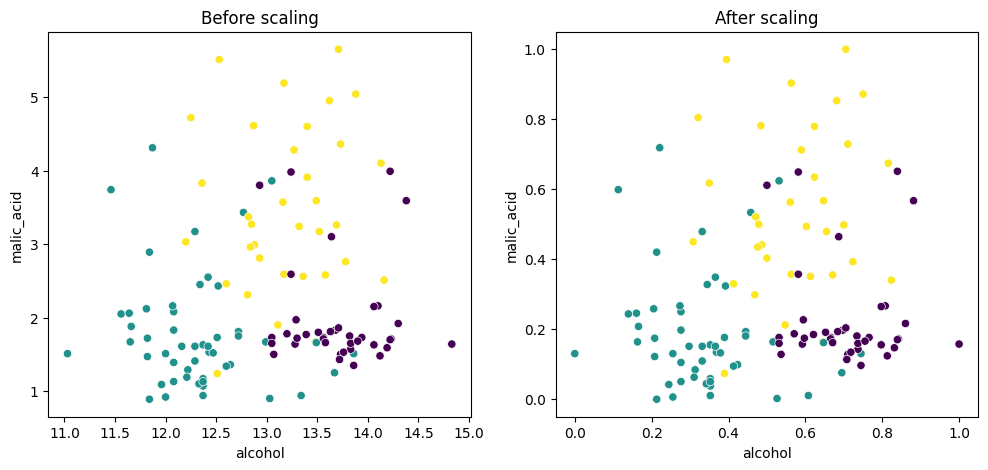

In [87]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.scatterplot(x=x_train['alcohol'], y=x_train['malic_acid'], c=y_train, ax=ax1)
ax1.set_title("Before scaling")

sns.scatterplot(x=x_train_scaled['alcohol'], y=x_train_scaled['malic_acid'], c=y_train, ax=ax2)
ax2.set_title("After scaling")

plt.show()

Text(0.5, 1.0, 'After MinMax Scaling')

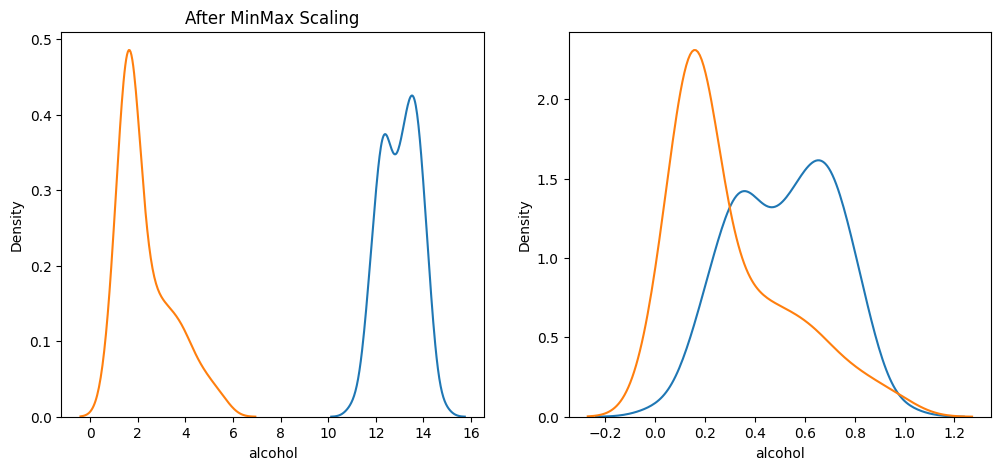

In [90]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(x_train['alcohol'], ax=ax1)
sns.kdeplot(x_train['malic_acid'], ax=ax1)
ax1.set_title("Before Scaling")

sns.kdeplot(x_train_scaled['alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['malic_acid'], ax=ax2)
ax1.set_title("After MinMax Scaling")

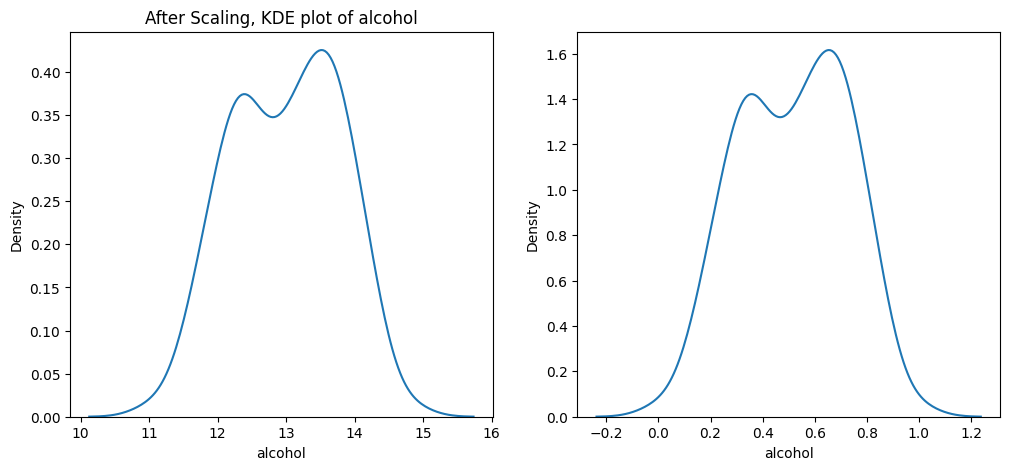

In [91]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(x_train['alcohol'], ax=ax1)
ax1.set_title("Before Scaling, KDE plot of alcohol")

sns.kdeplot(x_train_scaled['alcohol'], ax=ax2)
ax1.set_title("After Scaling, KDE plot of alcohol")

plt.show()